# LangGraph: Agents as State Machines

You built a tool-calling agent by hand in Class 6 — a `while` loop with tool dispatch. Today we rebuild that exact idea in LangGraph, then get for free everything the hand-rolled version couldn't do: durable state, pause/resume, human approval, time travel, and multi-agent routing.

Built against **LangGraph v1** (Oct 2025). We use OpenRouter for model access (free-tier friendly).

**Map:**
1. Hello-world graph
2. State + a tool
3. The agent loop (conditional edge) — *this is your Class 6 loop*
4. Checkpointer → memory
5. Interrupt → human-in-the-loop
6. Time travel
7. Subgraph + multi-agent
8. Streaming


## Setup

In [2]:
%pip install -q langgraph langchain langchain-openai langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 2.3 MB/s eta 0:00:00


In [3]:
from langchain_openai import ChatOpenAI
from google.colab import userdata

# Point the OpenAI client at OpenRouter
def make_llm(model="google/gemma-4-31b-it:free", **kw):
    return ChatOpenAI(
        model=model,
        api_key=userdata.get('OPENROUTER_API_KEY'),
        base_url="https://openrouter.ai/api/v1",
        **kw,
    )

llm = make_llm()
llm.invoke("Say 'graph online' and nothing else.").content


'graph online'

---
## Stage 1 — Hello-world graph

Three primitives: **State**, **Nodes**, **Edges**. A node reads state and returns a *partial* update. Edges decide what runs next. `START` and `END` are virtual nodes. You **must** compile before invoking.

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END

def echo(state: MessagesState):
    # nodes return an UPDATE, not the whole state
    return {"messages": [{"role": "ai", "content": "hello world"}]}

builder = StateGraph(MessagesState)
builder.add_node(echo)
builder.add_edge(START, "echo")
builder.add_edge("echo", END)
graph = builder.compile()

result = graph.invoke({"messages": [{"role": "user", "content": "hi"}]})
for m in result["messages"]:
    print(f"{m.type}: {m.content}")


human: hi
ai: hello world


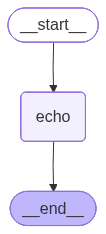

In [ ]:
# Visualize it — the graph IS the program
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


---
## Stage 2 — State + a tool

`MessagesState` is a prebuilt state with one `messages` key using the `add_messages` reducer (append + update-by-ID). We define a tool, bind it to the model, and let the model decide whether to call it.

In [ ]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    fake = {"paris": "18C, clear", "tokyo": "24C, rain", "nyc": "21C, cloudy"}
    return fake.get(city.lower(), "no data")

tools = [get_weather]
llm_with_tools = make_llm().bind_tools(tools)

# The model now emits tool_calls instead of a final answer when it wants the tool
resp = llm_with_tools.invoke([{"role": "user", "content": "weather in Tokyo?"}])
print("content:", resp.content)
print("tool_calls:", resp.tool_calls)


content: 
tool_calls: [{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'biu8uhb6', 'type': 'tool_call'}]


---
## Stage 3 — The agent loop

Here is the whole point. Your Class 6 loop was:

```
while not done:
    think → if tool_call: run tool, observe → else: done
```

In LangGraph that becomes: an **agent node**, a **tool node**, and a **conditional edge** that routes `tools` if the model asked for a tool, else `END`. The `tools → agent` edge closes the loop.

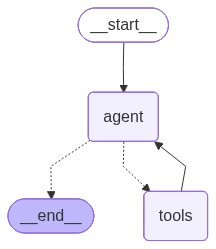

In [ ]:
# ToolNode executes tool calls. In v1 the recommended import is from langchain.tools;
# the older `from langgraph.prebuilt import ToolNode` still works if you're on an older build.
try:
    from langchain.tools import ToolNode
except ImportError:
    from langgraph.prebuilt import ToolNode

def agent(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

def route(state: MessagesState):
    last = state["messages"][-1]
    return "tools" if last.tool_calls else END

builder = StateGraph(MessagesState)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", route, {"tools": "tools", END: END})
builder.add_edge("tools", "agent")   # <-- this edge is the loop
agent_graph = builder.compile()

display(Image(agent_graph.get_graph().draw_mermaid_png()))


In [ ]:
out = agent_graph.invoke({"messages": [{"role": "user", "content": "What's the weather in Paris and Tokyo?"}]})
for m in out["messages"]:
    print(f"{m.type:9} | {m.content}  {getattr(m, 'tool_calls', '')}")


human     | What's the weather in Paris and Tokyo?  
ai        |   [{'name': 'get_weather', 'args': {'city': 'Paris'}, 'id': 'wfw4cg5i', 'type': 'tool_call'}, {'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'u8tuknh1', 'type': 'tool_call'}]
tool      | 18C, clear  
tool      | 24C, rain  
ai        | The weather in Paris is 18°C and clear, while in Tokyo it is 24°C and raining.  []


---
## Stage 4 — Memory via a checkpointer

Compile with a checkpointer and the graph snapshots its state at every super-step, keyed by `thread_id`. Same thread = remembers. New thread = fresh.

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

mem_graph = builder.compile(checkpointer=InMemorySaver())

cfg = {"configurable": {"thread_id": "user-1"}}
mem_graph.invoke({"messages": [{"role": "user", "content": "Weather in NYC?"}]}, cfg)

# Second turn, same thread — no need to repeat context
out = mem_graph.invoke({"messages": [{"role": "user", "content": "And is that warmer than Paris?"}]}, cfg)
print(out["messages"][-1].content)


Since I couldn't retrieve the temperature for New York City, I can't determine if it's warmer than Paris, which is currently 18°C and clear.


In [ ]:
# Inspect the saved state
snap = mem_graph.get_state(cfg)
print("messages in thread:", len(snap.values["messages"]))
print("next nodes:", snap.next)


messages in thread: 8
next nodes: ()


---
## Stage 5 — Human-in-the-loop with interrupt

`interrupt()` pauses the graph and hands control back. The human inspects, then resumes with `Command(resume=...)`, whose value becomes the return of `interrupt()`. Requires a checkpointer (it needs to save the paused state).

**Two ways to drive it, both current:**
- `invoke(..., version="v2")` returns a `GraphOutput` with `.value` and `.interrupts`. (The old `result["__interrupt__"]` dict access still works but is **deprecated** — migrate to `.interrupts`.)
- `stream_events(..., version="v3")` surfaces it on `stream.interrupted` / `stream.interrupts` — preferred when also streaming tokens.

**The rules of interrupt (gotchas):** on resume, the node re-runs *from the top* — so (1) never wrap `interrupt()` in a bare `try/except` (it swallows the pause exception), (2) keep interrupt calls in the same order every run (matching is index-based — no conditional/looped interrupts), (3) pass only JSON-serializable payloads, (4) any side effect before an `interrupt()` must be idempotent (it will run again).

In [ ]:
from langgraph.types import interrupt, Command

def approve_tool(state: MessagesState):
    last = state["messages"][-1]
    if last.tool_calls:
        decision = interrupt({"action": "approve tool call?", "calls": last.tool_calls})
        if decision != "yes":
            return {"messages": [{"role": "ai", "content": "Tool call cancelled by human."}]}
    return state

hb = StateGraph(MessagesState)
hb.add_node("agent", agent)
hb.add_node("approve", approve_tool)
hb.add_node("tools", ToolNode(tools))
hb.add_edge(START, "agent")
hb.add_conditional_edges("agent", route, {"tools": "approve", END: END})
hb.add_edge("approve", "tools")
hb.add_edge("tools", "agent")
hil_graph = hb.compile(checkpointer=InMemorySaver())

# --- version=v2 invoke: GraphOutput.interrupts ---
cfg = {"configurable": {"thread_id": "hil-1"}}
res = hil_graph.invoke(
    {"messages": [{"role": "user", "content": "Weather in Tokyo?"}]},
    config=cfg, version="v2",
)
print("interrupts:", res.interrupts)   # tuple[Interrupt, ...]; .value holds your payload


interrupts: (Interrupt(value={'action': 'approve tool call?', 'calls': [{'name': 'get_weather', 'args': {'city': 'Tokyo'}, 'id': 'eobbxr78', 'type': 'tool_call'}]}, id='59bec75ec50e26b43ae76a586fa338d8'),)


In [ ]:
# Human approves -> resume (same thread)
final = hil_graph.invoke(Command(resume="yes"), config=cfg, version="v2")
print(final.value["messages"][-1].content)


The current weather in Tokyo is 24°C with rain.


In [ ]:
# --- stream_events(version="v3"): typed projections, preferred with token streaming ---
cfg2 = {"configurable": {"thread_id": "hil-2"}}
stream = hil_graph.stream_events(
    {"messages": [{"role": "user", "content": "Weather in Paris?"}]},
    config=cfg2, version="v3",
)
_ = stream.output            # drive the run to the pause
print("interrupted:", stream.interrupted)
print("payload:", stream.interrupts)

resumed = hil_graph.stream_events(Command(resume="yes"), config=cfg2, version="v3")
print(resumed.output["messages"][-1].content)


/usr/local/lib/python3.12/dist-packages/langgraph/pregel/main.py:3675: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
/usr/local/lib/python3.12/dist-packages/langgraph/pregel/main.py:3525: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


interrupted: True
payload: [Interrupt(value={'action': 'approve tool call?', 'calls': [{'name': 'get_weather', 'args': {'city': 'Paris'}, 'id': 'chatcmpl-tool-b244ca9536b46989', 'type': 'tool_call'}]}, id='b8980f0f72a6f627ae879ce38a9bcd2e')]
[{'type': 'text', 'text': 'The current weather in Paris is 18°C and clear.', 'index': 0}]


---
## Stage 6 — Time travel

Every checkpoint is replayable. List history, rewind to a checkpoint, or `update_state` to fork an alternate branch.

In [ ]:
history = list(mem_graph.get_state_history(cfg))
print(f"{len(history)} checkpoints (reverse-chronological)\n")
for h in history:
    print(f"step {h.metadata['step']:>2} | next={h.next} | msgs={len(h.values.get('messages', []))}")


0 checkpoints (reverse-chronological)



In [ ]:
mem_cfg = {"configurable": {"thread_id": "user-1"}}
history = list(mem_graph.get_state_history(mem_cfg))

# Diagnosis: If history is empty, next() will raise StopIteration
if not history:
    print("Error: No history found for thread 'user-1'. Run a cell with this thread_id first.")
elif not any(h.next for h in history):
    print("Error: Found history, but no checkpoints have a pending 'next' node to replay.")
else:
    try:
        # Safe retrieval of the latest checkpoint with a pending node
        earlier = next(h for h in history if h.next)
        print(f"Replaying from step {earlier.metadata['step']}, next node: {earlier.next}")
        forked = mem_graph.invoke(None, earlier.config)
        print("Replay tail:", forked["messages"][-1].content)
    except StopIteration:
        print("StopIteration: No suitable checkpoint found in the history list.")

Replaying from step 8, next node: ('agent',)
Replay tail: I'm sorry, but since I couldn't retrieve the weather for New York City, I cannot determine if it is warmer than Paris, which is currently 18°C and clear.


In [ ]:
# FORK: update_state creates a NEW branch from a past checkpoint (original history stays intact).
# It returns a new config; invoke(None, fork_config) continues from the fork.
fork_config = mem_graph.update_state(
    earlier.config,
    values={"messages": [{"role": "user", "content": "Actually, weather in Tokyo instead?"}]},
)
fork_result = mem_graph.invoke(None, fork_config)
print("Forked tail:", fork_result["messages"][-1].content)


Forked tail: The current weather in Tokyo is 24°C with rain.


---
## Stage 7 — Subgraphs + multi-agent

A compiled graph can be a node inside another graph (a **subgraph**). A common pattern: a **supervisor** that routes to specialist workers. Workers hand control back to the parent with `Command(goto=..., graph=Command.PARENT)`.

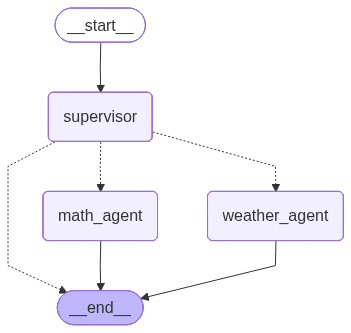

In [ ]:
from typing import Literal
from typing_extensions import TypedDict

class SuperState(TypedDict):
    messages: list
    next_agent: str

def supervisor(state: SuperState) -> Command[Literal["weather_agent", "math_agent", "__end__"]]:
    last = state["messages"][-1]["content"].lower()
    if "weather" in last:
        return Command(goto="weather_agent", update={"next_agent": "weather"})
    if any(c.isdigit() for c in last):
        return Command(goto="math_agent", update={"next_agent": "math"})
    return Command(goto=END)

def weather_agent(state: SuperState):
    out = agent_graph.invoke({"messages": state["messages"]})
    return {"messages": state["messages"] + [{"role": "ai", "content": out["messages"][-1].content}]}

def math_agent(state: SuperState):
    q = state["messages"][-1]["content"]
    ans = make_llm().invoke(f"Solve, answer only: {q}").content
    return {"messages": state["messages"] + [{"role": "ai", "content": ans}]}

sb = StateGraph(SuperState)
sb.add_node("supervisor", supervisor)
sb.add_node("weather_agent", weather_agent)
sb.add_node("math_agent", math_agent)
sb.add_edge(START, "supervisor")
sb.add_edge("weather_agent", END)
sb.add_edge("math_agent", END)
multi = sb.compile()

display(Image(multi.get_graph().draw_mermaid_png()))


In [ ]:
for q in ["What's the weather in Paris?", "What is 17 * 23?"]:
    out = multi.invoke({"messages": [{"role": "user", "content": q}], "next_agent": ""})
    print(f"Q: {q}\nA: {out['messages'][-1]['content']}\n")


Q: What's the weather in Paris?
A: The current weather in Paris is 18°C and clear.

Q: What is 17 * 23?
A: 391



### Durable execution & fault tolerance
Durable execution is *on* whenever you compile with a checkpointer. You can tune *when* state is written with the `durability` argument on `invoke`/`stream`:
- `"exit"` — persist only when the run exits (fastest; no mid-run crash recovery)
- `"async"` — persist asynchronously alongside the next step (good balance)
- `"sync"` — persist before each step starts (most durable, some overhead)

On a crash, resume with the **same `thread_id`** and `None` as input — completed work isn't re-run. Wrap non-deterministic work or side-effects in `@task` (from `langgraph.func`) so they aren't repeated on replay. (`langgraph>=1.2` also adds cooperative graceful shutdown via `RunControl` / `request_drain()` for SIGTERM handling.)

### Subgraph persistence modes
A compiled subgraph's `checkpointer=` argument controls its state across calls: `None` (default) = per-invocation (fresh each call, inherits parent's checkpointer within a call so interrupts still work); `True` = per-thread (remembers across calls — multi-turn subagent memory; avoid parallel calls to the same one); `False` = stateless (no checkpointing, no interrupts). Inspect with `graph.get_state(config, subgraphs=True)`.

### Functional API (alternative to the Graph API)
Same runtime, different authoring style: decorate an `@entrypoint(checkpointer=...)` function and mark units of work with `@task` (both from `langgraph.func`). You write plain Python control flow and still get persistence, streaming, and HITL. Reach for it when control flow is easier as code than as an explicit node/edge graph.

### create_agent + middleware (the LangChain layer)
For standard ReAct agents you don't have to hand-build the loop — `from langchain.agents import create_agent` does it (it uses `ToolNode` internally). You extend it with **middleware** from `langchain.agents.middleware`: hooks `@before_model`, `@after_model`, `@wrap_model_call`, `@wrap_tool_call`, `@before_agent`, `@after_agent`, plus `@dynamic_prompt`. That's where guardrails, summarization, PII redaction, retries, dynamic model/tool selection live. Prebuilt middleware exists (e.g. tool-call-limit, model-retry, HITL).

### Structured output
`create_agent(..., response_format=Schema)` returns a validated object in `result["structured_response"]`. Strategies: `ToolStrategy` (artificial tool-calling, works anywhere) and `ProviderStrategy` (provider-native). As of langchain 1.0, passing a bare schema defaults to `ProviderStrategy` when supported, else falls back to `ToolStrategy`. Note: agent custom-state schemas **must be `TypedDict`** in v1 — Pydantic/dataclasses are no longer accepted there.